In [23]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

import numpy as np

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

/home/das214/SmartPix/SoftQuantize


In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [24]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"
# dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
print(os.listdir(dataset_base_dir))

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t_N_0.0mu_80.0sig_NoLog_Stdr")
print(os.listdir(os.path.join(dataset_base_dir, "TFR_files")))
print(os.listdir(tfrecords_base_dir))

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

['train', 'test', 'TFR_files']
['2t_N_0.0mu_80.0sig_NoLog_Stdr', '2t_N_0.0mu_80.0sig', '2t_N_0.0mu_400.0sig', 'TRanf2_2t_N_0.0mu_80.0sig']
['TFR_val', 'TFR_train']


In [25]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)

print("num train batches:", len(training_generator))
print("num val batches  :", len(validation_generator))

b = 0
X, y = training_generator[b]
X = X.numpy()
y = y.numpy()

print("X shape:", X.shape, "dtype:", X.dtype)   # expect (B, H, W, C) or similar
print("y shape:", y.shape, "dtype:", y.dtype)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json


num train batches: 84
num val batches  : 21
X shape: (5000, 16, 16, 2) dtype: float32
y shape: (5000, 4) dtype: float32


In [28]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

In [33]:
def create_model(input_shape=None,
                     final_outputs=None,
                     initial_thresholds=None,
                     threshold_offset=None):
  inp = layers.Input(shape=input_shape, name="raw_input")
  q_out = SoftQuantizeLayer(
      n_bits=2,
      initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
      threshold_offset=threshold_offset,
      initial_thresholds=initial_thresholds,
      trainable_levels=False,
      trainable_thresholds=True,
      initial_k=1.0,
      trainable_k=True,
      name="soft_quantizer_output"
  )(inp)

  return keras.Model(inputs=inp, outputs=q_out)

model_params = {
    'input_shape': (16,16,2),
    'final_outputs': 14,
    'initial_thresholds': [249.30, 667.66, 1659.27],
    'threshold_offset': 80.0
}

model = create_model(**model_params)

In [126]:
b = 0
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0 1 2 3]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0 1 2 3]


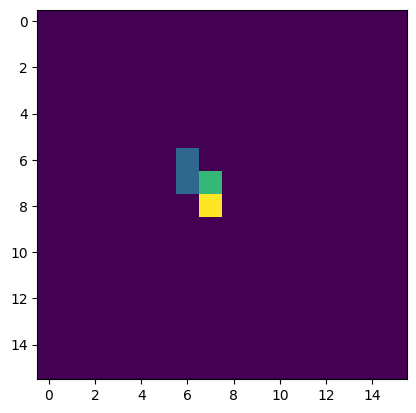

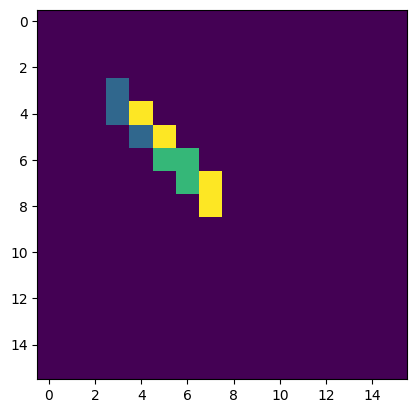

In [127]:
plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

In [144]:
from collections import Counter

def extract_patches(Q, patch_dim, stride=None):
    """
    Q: (B,H,W,C) with discrete values in {0,1,2,3} (or floats very close to those)
    patch_dim: (pH,pW)
    stride: (dY,dX) or None -> non-overlapping
    Returns: list of patch tuples (flattened) over (b,c,y,x) tiles.
    """
    B, H, W, C = Q.shape
    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    patches_ctr = Counter()
    for b in range(B):
        for c in range(C):
            for y in range(0, H - pH + 1, dY):
                for x in range(0, W - pW + 1, dX):
                    patch = Q[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    patches_ctr[key] += 1
    return patches_ctr

In [156]:
patch_dim = (1, 1)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)

#patches: 2560000
#unique patches: 4


In [157]:
patches_ctr.values()

dict_values([2460611, 34502, 24447, 40440])

In [160]:
16*16*2*5000

2560000

In [153]:
patch_dim = (4, 4)
patches_ctr = extract_patches(Q, patch_dim)

print("num patches:", len(patches))
print("first 5 patches:")

levels = set()
for p in patches:
    levels |= set(p)

print("levels seen in patches:", levels)

for p in patches[:5]:
    print(p)

print("Top 10 patches:")
for pat, cnt in patches_ctr.most_common(10):
    print(pat, cnt)

num patches: 40000
first 5 patches:
levels seen in patches: {0, 1, 2, 3}
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0

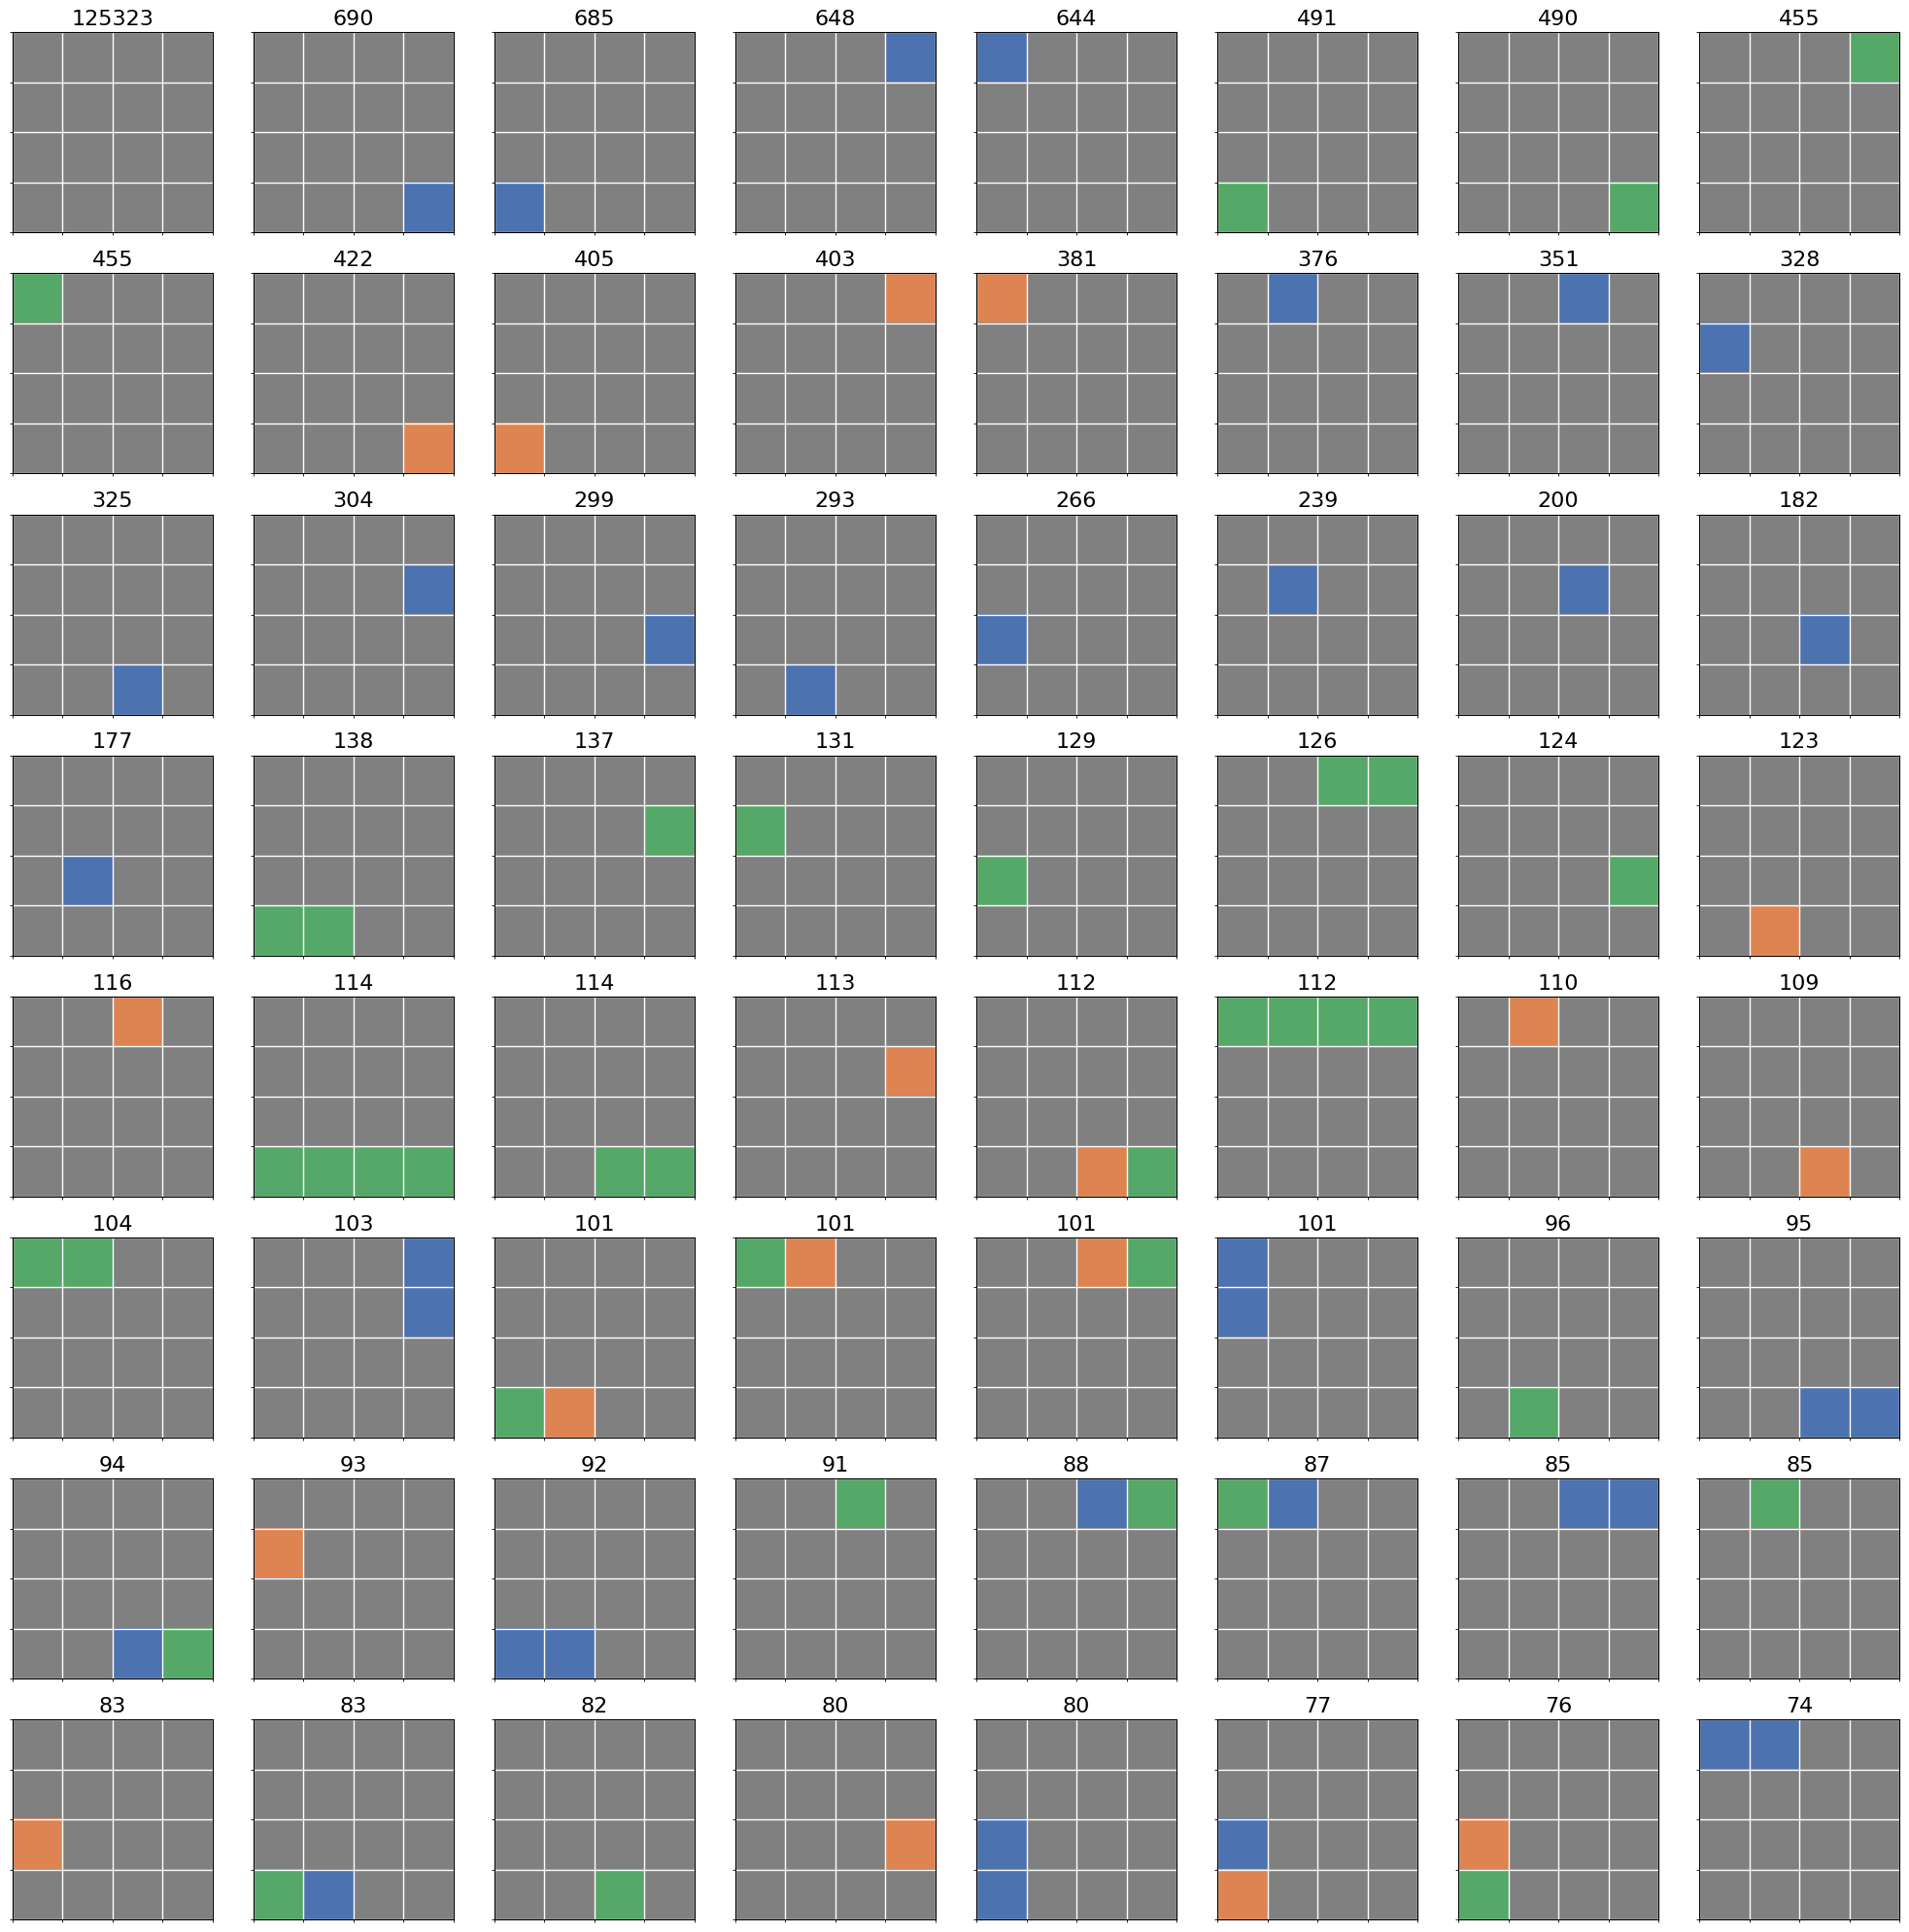

In [147]:
K = 64

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()


In [148]:
def estimate_bits_per_cell_from_topK(patches_ctr, pH, pW, K, bits_per_entry=2):
    """
    Simple top-K dictionary + ESC model:
      - encode symbol among (top-K patches + ESC) with ideal entropy H_sym (lower bound)
      - if ESC, transmit raw patch payload (pH*pW*bits_per_entry)

    Returns: (bits_per_cell, p_esc, H_sym_bits_per_patch)
    """
    total = sum(patches_ctr.values())  # total patch *occurrences*
    top = patches_ctr.most_common(K)
    top_counts = np.array([cnt for _, cnt in top], dtype=np.float64)

    p_top = top_counts / total
    p_esc = max(0.0, 1.0 - float(p_top.sum()))  # clamp for numerical safety

    # symbol distribution over K+1 symbols (K dictionary entries + ESC)
    p_sym = np.concatenate([p_top, np.array([p_esc])])
    # avoid log(0)
    p_nonzero = p_sym[p_sym > 0]
    H_sym = -np.sum(p_nonzero * np.log2(p_nonzero))  # bits per patch for symbol (ideal)

    raw_payload_bits = (pH * pW * bits_per_entry)  # sent only on ESC
    bits_per_patch = H_sym + p_esc * raw_payload_bits
    bits_per_cell = bits_per_patch / (pH * pW)

    return bits_per_cell, p_esc, H_sym

In [152]:
patch_dims = [(1,1), (2,2), (3,3), (4,4), (8,8)]
Ks = [8, 16, 32, 64, 128, 256, 512]

rows = []

print(f"{'patch':>9} {'K':>6} {'Keff':>6} {'bits/cell':>10} {'p_esc':>10} {'Hsym(b/patch)':>14} {'#patches':>10} {'#unique':>10}")

for (pH, pW) in patch_dims:
    patches_ctr = extract_patches(Q_int, (pH, pW), stride=None)  # non-overlapping
    npatch = sum(patches_ctr.values())
    nuniq  = len(patches_ctr)

    for K in Ks:
        K_eff = min(K, nuniq) if nuniq > 0 else 0

        bits_cell, p_esc, Hsym = estimate_bits_per_cell_from_topK(
            patches_ctr, pH, pW, K_eff, bits_per_entry=2
        )

        print(f"{str((pH,pW)):>9} {K:6d} {K_eff:6d} {bits_cell:10.4f} {p_esc:10.4f} {Hsym:14.4f} {npatch:10d} {nuniq:10d}")

        rows.append((pH, pW, K_eff, bits_cell, p_esc, Hsym, npatch, nuniq))


    patch      K   Keff  bits/cell      p_esc  Hsym(b/patch)   #patches    #unique
   (1, 1)      8      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     16      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     32      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     64      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    128      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    256      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    512      4     0.2973     0.0000         0.2973    2560000          4
   (2, 2)      8      8     0.2675     0.0594         0.5949     640000        256
   (2, 2)     16     16     0.2556     0.0390         0.7102     640000        256
   (2, 2)     32     32     0.2517     0.0263         0.7962     640000        256
   (2, 2)     64     64     0.2483     0.0131         0.8886     640000        256
   (

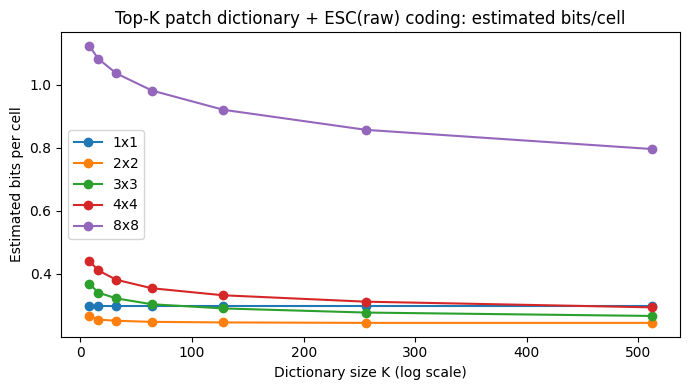

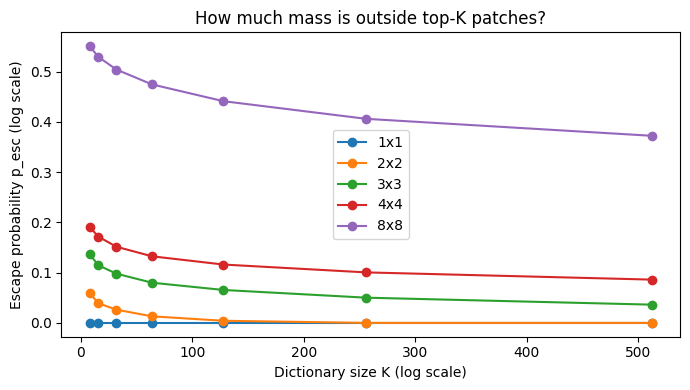

In [143]:
# ---- Plot: bits/cell vs K for each patch_dim ----
plt.figure(figsize=(7,4))
for (pH,pW) in patch_dims:
    xs = []
    ys = []
    for K in Ks:
        for r in rows:
            if r[0]==pH and r[1]==pW and r[2]==K:
                xs.append(K)
                ys.append(r[3])
                break
    plt.plot(xs, ys, marker='o', label=f"{pH}x{pW}")

# plt.xscale("log")
plt.xlabel("Dictionary size K (log scale)")
plt.ylabel("Estimated bits per cell")
plt.title("Top-K patch dictionary + ESC(raw) coding: estimated bits/cell")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: p_esc vs K (to see when dictionary is 'covering' the mass) ----
plt.figure(figsize=(7,4))
for (pH,pW) in patch_dims:
    xs = []
    ys = []
    for K in Ks:
        for r in rows:
            if r[0]==pH and r[1]==pW and r[2]==K:
                xs.append(K)
                ys.append(r[4])
                break
    plt.plot(xs, ys, marker='o', label=f"{pH}x{pW}")

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Dictionary size K (log scale)")
plt.ylabel("Escape probability p_esc (log scale)")
plt.title("How much mass is outside top-K patches?")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, 'weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5')

In [14]:
checkpoint_filepath

'./trained_models/model-c6103ed3-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [15]:
# 9f5e5c2c : 1000 epochs
print(fingerprint)

c6103ed3


In [16]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

class SoftQuantizeLoggerCallback(Callback):
    def __init__(self, log_filepath, layer_name="soft_quantizer_output"):
        super().__init__()
        self.log_filepath = log_filepath
        self.layer_name = layer_name
        self.header_written = False

    def on_train_begin(self, logs=None):
        os.makedirs(os.path.dirname(self.log_filepath), exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        try:
            layer = self.model.get_layer(self.layer_name)
            if not hasattr(layer, 'n_bits'):
                 print(f"\nWarning: Layer '{self.layer_name}' is not a SoftQuantizeLayer. Skipping logging.")
                 return
        except ValueError:
            print(f"\nWarning: Layer '{self.layer_name}' not found in the model. Skipping logging.")
            return

        if not self.header_written:
            num_levels = layer.num_levels
            num_thresholds = num_levels - 1
            
            header = ['epoch', 'k']
            header.extend([f'level_{i}' for i in range(num_levels)])
            header.extend([f'threshold_{i}' for i in range(num_thresholds)])

            header.append('raw_first_level')
            header.extend([f'raw_log_level_delta_{i}' for i in range(num_levels - 1)])
            header.append('raw_first_threshold')
            if hasattr(layer, 'log_threshold_deltas'):
                header.extend([f'raw_log_threshold_delta_{i}' for i in range(num_thresholds - 1)])

            with open(self.log_filepath, mode='w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(header)
            self.header_written = True

        k_val = layer.k.numpy().item()
        levels = layer.levels.numpy().tolist()
        thresholds = layer.thresholds.numpy().tolist()
        
        first_level = layer.first_level.numpy().item()
        log_level_deltas = layer.log_level_deltas.numpy().tolist()
        first_threshold = layer.first_threshold.numpy().item()
        
        row_data = [epoch, k_val]
        row_data.extend(levels)
        row_data.extend(thresholds)
        row_data.append(first_level)
        row_data.extend(log_level_deltas)
        row_data.append(first_threshold)
        
        if hasattr(layer, 'log_threshold_deltas'):
            log_threshold_deltas = layer.log_threshold_deltas.numpy().tolist()
            row_data.extend(log_threshold_deltas)
        
        with open(self.log_filepath, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row_data)


csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)
scheduler_callback = AnnealingScheduler(
    schedule='cosine',  
    target_layer_name='soft_quantizer_output', 
    initial_k=1.0,
    final_k=67.0, 
    verbose=1      
)

quantizer_logger = SoftQuantizeLoggerCallback(
    log_filepath=f"{base_dir}/soft_quantizer_state_log.csv", # New, more descriptive filename
    layer_name="soft_quantizer_output"
)


In [ ]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        # callbacks=[mcp, csv_logger, scheduler_callback, quantizer_logger],
        callbacks=[mcp, csv_logger],
        epochs=1000,
        shuffle=False,
        verbose=1
    )

Epoch 1/1000


2025-11-18 23:45:34.417125: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-11-18 23:45:34.918478: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-11-18 23:45:35.957416: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x564d063e2820
2025-11-18 23:45:38.005189: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa15db1c2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-18 23:45:38.005254: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB MIG 7g.40gb, Compute Capability 8.0
2025-11-18 23:45:38.284617: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763505938.842280 1280334 device_compiler.h:186] Compile

64/64 [==============================] - 18s 112ms/step - loss: 42945.0312 - val_loss: 14258.1328
Epoch 2/1000
64/64 [==============================] - 6s 92ms/step - loss: 11570.5420 - val_loss: 10058.9531
Epoch 3/1000
64/64 [==============================] - 6s 93ms/step - loss: 8895.4893 - val_loss: 7737.2378
Epoch 4/1000
64/64 [==============================] - 6s 94ms/step - loss: 6025.3242 - val_loss: 5006.6636
Epoch 5/1000
64/64 [==============================] - 6s 93ms/step - loss: 4120.0532 - val_loss: 3848.4451
Epoch 6/1000
64/64 [==============================] - 6s 89ms/step - loss: 3108.9773 - val_loss: 3143.0298
Epoch 7/1000
64/64 [==============================] - 6s 91ms/step - loss: 2401.6587 - val_loss: 2615.6489
Epoch 8/1000
64/64 [==============================] - 6s 94ms/step - loss: 2182.2820 - val_loss: 2682.8506
Epoch 9/1000
64/64 [==============================] - 6s 92ms/step - loss: 1897.3402 - val_loss: 1790.1234
Epoch 10/1000
64/64 [=======================

In [26]:
print(history.history.keys())
print(history.history['loss'][:5])
print(history.history['val_loss'][:5])


dict_keys(['loss', 'val_loss'])
[42945.03125, 11570.5419921875, 8895.4892578125, 6025.32421875, 4120.05322265625]
[14258.1328125, 10058.953125, 7737.23779296875, 5006.66357421875, 3848.445068359375]


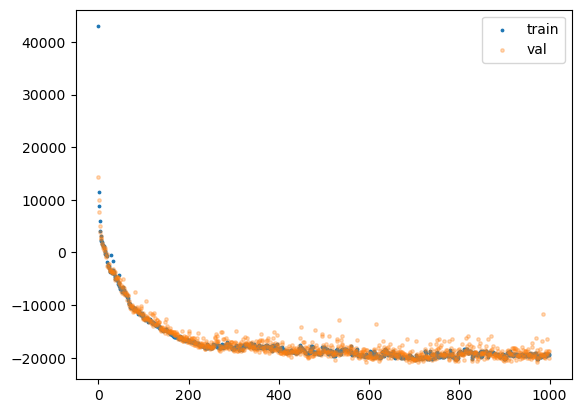

In [33]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.show()


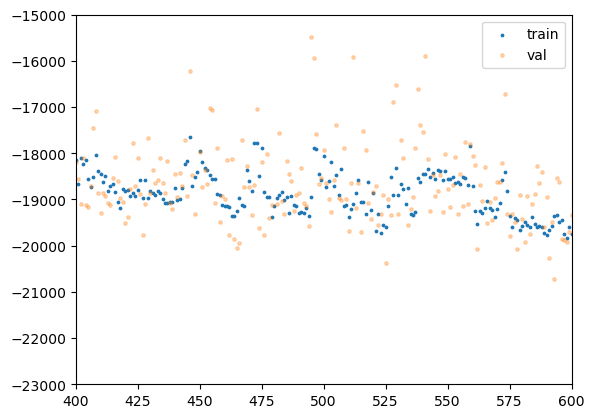

In [36]:
import matplotlib.pyplot as plt

epochs_vals = range(1000)
plt.scatter(epochs_vals, history.history['loss'], label='train', alpha = 1.0, s = 3)
plt.scatter(epochs_vals, history.history['val_loss'], label='val', alpha = 0.3, s = 6)
plt.legend()
plt.xlim([400, 600])
plt.ylim([-23_000, -15_000])
plt.show()
